# Fraud Detection Demo — Training Notebook

**Dataset:** Sparkov credit-card transaction simulation ([Kaggle: kartik2112/fraud-detection](https://www.kaggle.com/datasets/kartik2112/fraud-detection)) — ~1.9M human-readable transactions, ~0.6% fraud.

**Pipeline:** load → EDA → feature engineering → XGBoost → evaluation → SHAP → LLM-style report.

Run from the **repo root** so `src` imports resolve.

In [1]:
# If running in Colab / a fresh venv, uncomment:
# !pip install -q pandas numpy scikit-learn xgboost shap duckdb pyarrow matplotlib joblib kagglehub

In [2]:
import os, sys, json
# Resolve repo root robustly (works from repo root AND from notebooks/)
root = os.getcwd()
while root != os.path.dirname(root) and not os.path.isdir(os.path.join(root, 'src')):
    root = os.path.dirname(root)
os.chdir(root)
sys.path.insert(0, root)

import pandas as pd
import matplotlib.pyplot as plt

# --- Load data -------------------------------------------------------------
# Real dataset:  python -m scripts.download_data   (then concatenate train+test)
# Fallback:      synthetic Sparkov-schema sample generated on the fly
path = 'data/raw/all.csv'
if not os.path.exists(path):
    print('real dataset not found — generating synthetic sample instead')
    from scripts.make_sample_data import generate
    path = generate(n=30000)
df = pd.read_csv(path)
print(f'{len(df):,} rows | fraud rate {df.is_fraud.mean():.4%}')
df.head(3)

real dataset not found — generating synthetic sample instead


30,000 rows | fraud rate 0.9133%


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-05 11:38:00,4189816874402029,Garcia Store,gas_transport,13.90,James,Johnson,M,6558 Smith St,Austin,...,30.255033,-97.706394,965000,Engineer,1995-06-10,131e4998d8e6429caae8aa13bac90daf,1591357080,30.263632,-97.785799,0
1,2020-01-18 19:50:00,4305898219634229,Garcia Store,grocery_pos,266.63,Elizabeth,Garcia,M,9693 Martinez St,Portland,...,45.469139,-122.636689,650000,Teacher,1971-07-07,a3357c9aa49e40ddad6eb3c839be1e53,1579377000,45.496868,-122.588181,0
2,2020-03-02 00:34:00,4565442550485113,Davis Store,grocery_pos,11.90,Michael,Smith,F,7696 Davis St,Miami,...,25.764393,-80.170399,440000,Manager,1982-09-13,c53dcb4773354d82bbfb1c11ab3ab1c7,1583109240,25.659999,-80.174309,0


## 1. Quick EDA — why fraud detection is hard (class imbalance)

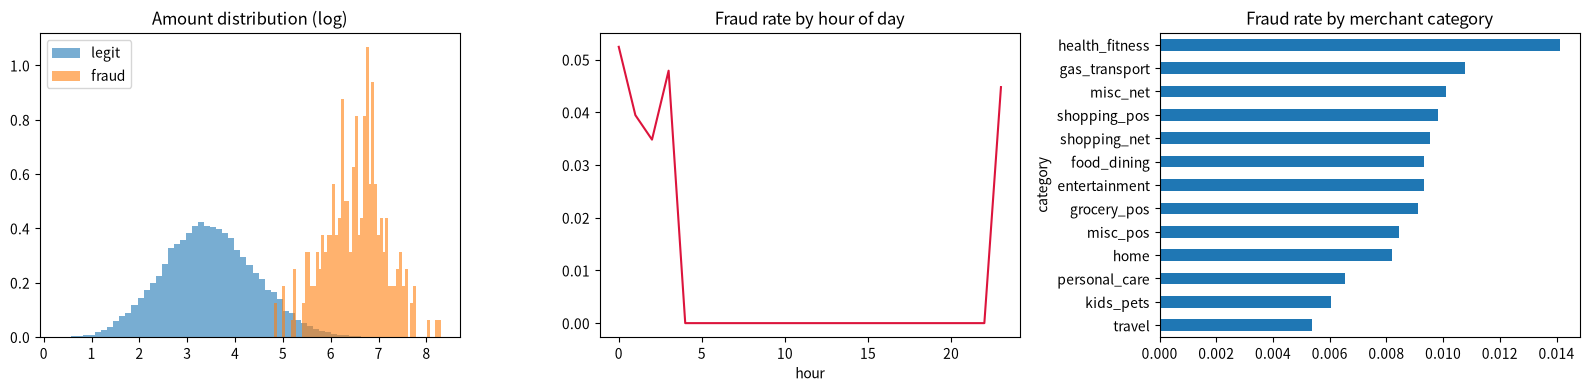

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['amt_log'] = __import__('numpy').log1p(df['amt'])
for label, sub in df.groupby('is_fraud'):
    axes[0].hist(sub['amt_log'], bins=60, alpha=0.6, density=True,
                 label='fraud' if label else 'legit')
axes[0].set_title('Amount distribution (log)'); axes[0].legend()

hr = pd.to_datetime(df['trans_date_trans_time']).dt.hour
df.assign(hour=hr).groupby(['hour','is_fraud']).size().unstack(fill_value=0)\
  .pipe(lambda d: (d[1]/d.sum(axis=1))).plot(ax=axes[1], color='crimson')
axes[1].set_title('Fraud rate by hour of day')

df.groupby('category')['is_fraud'].mean().sort_values().plot.barh(ax=axes[2])
axes[2].set_title('Fraud rate by merchant category')
plt.tight_layout(); plt.show()

## 2. Feature engineering

Behavioural signals: amount z-score vs. the customer's own history, distance from home to merchant (haversine), night-time flag, 24h transaction velocity, plus category one-hots.

In [4]:
from src.features import engineer, BASE_FEATURES
fe, _ = engineer(df.sample(min(5000, len(df)), random_state=1), fit=True)
fe[BASE_FEATURES].describe().T[['mean','min','max']]

,mean,min,max
amt,5.686954e+01,1.040000,3148.360000
amt_log,3.484475e+00,0.712950,8.054955
hour,1.132700e+01,0.000000,23.000000
day_of_week,3.016400e+00,0.000000,6.000000
is_weekend,2.818000e-01,0.000000,1.000000
is_night,2.984000e-01,0.000000,1.000000
distance_km,1.928367e+01,0.298121,1063.368259
city_pop_log,1.313963e+01,11.661354,13.779884
age,4.379505e+01,21.253936,65.259411
gender_m,4.962000e-01,0.000000,1.000000


## 3. Train XGBoost (time-based split — last 20% of the timeline is held out)

In [5]:
from src.train import train
metrics = train(df, out_dir='artifacts')
print(json.dumps(metrics, indent=2))

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{
  "roc_auc": 1.0,
  "pr_auc": 1.0,
  "threshold_f1_max": 0.9956743121147156,
  "precision_at_threshold": 1.0,
  "recall_at_threshold": 1.0,
  "confusion_matrix": [
    [
      5944,
      0
    ],
    [
      0,
      56
    ]
  ],
  "train_rows": 24000,
  "test_rows": 6000,
  "fraud_rate_train": 0.009083333333333334
}


## 4. Global explainability — SHAP feature importance

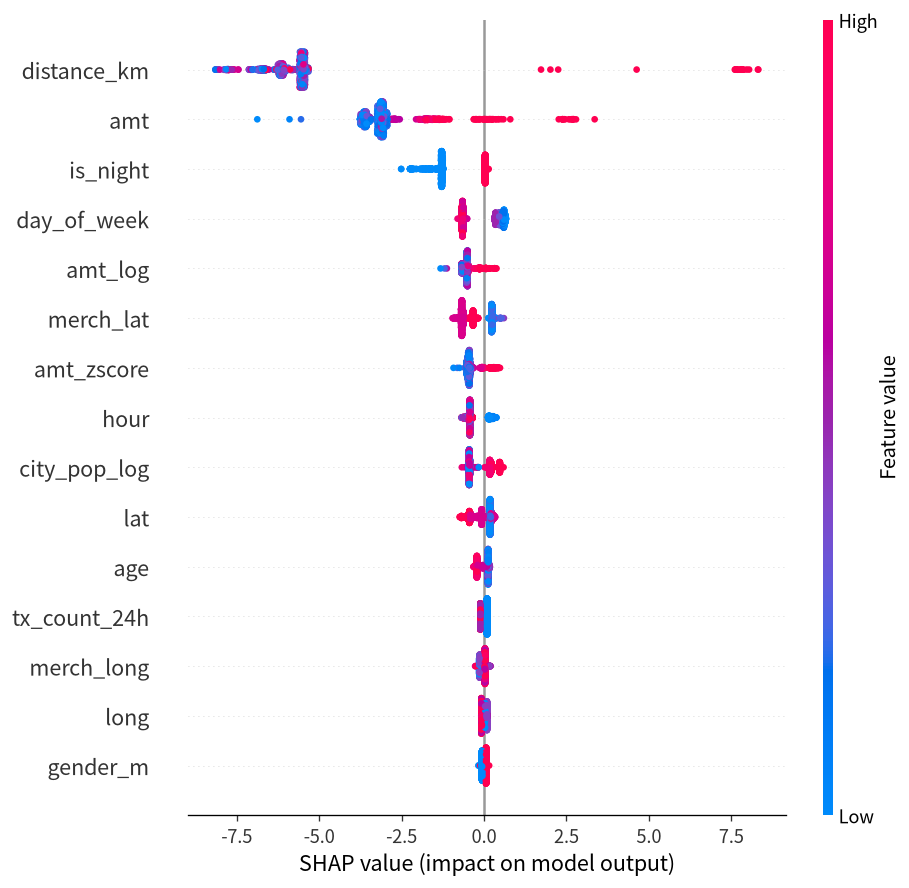

In [6]:
from IPython.display import Image
Image('artifacts/shap_summary.png')

## 5. Score new transactions + per-flag SHAP drivers

In [7]:
from src.scorer import load_bundle, score, shap_explain

bundle = load_bundle('artifacts/model.joblib')
sample = df.sample(2000, random_state=7)
proba, pred = score(sample, bundle)
flagged = sample[pred == 1].copy()
flagged['fraud_probability'] = proba[pred == 1]
print(f'{len(flagged)} flagged of {len(sample)} '
      f'(true frauds caught: {int(flagged.is_fraud.sum())}/{int(sample.is_fraud.sum())})')
flagged[['trans_date_trans_time','first','last','merchant','amt','fraud_probability','is_fraud']].head(10)

19 flagged of 2000 (true frauds caught: 19/19)


,trans_date_trans_time,first,last,merchant,amt,fraud_probability,is_fraud
1910,2020-04-13 02:39:00,Mary,Williams,fraud_Jones Inc,421.12,0.999975,1
9787,2020-02-10 01:15:00,James,Smith,fraud_Martinez Inc,853.13,0.999892,1
16219,2020-05-29 02:45:00,Robert,Brown,fraud_Brown Inc,271.48,0.999971,1
28022,2020-01-26 02:02:00,Mary,Miller,fraud_Miller Inc,991.88,0.999991,1
717,2020-06-14 23:36:00,Joseph,Davis,fraud_Garcia Inc,1928.52,0.999978,1
28796,2020-04-06 02:40:00,Patricia,Martinez,fraud_Brown Inc,2350.54,0.999993,1
1897,2020-06-14 23:50:00,Joseph,Brown,fraud_Johnson Inc,185.30,0.997613,1
20330,2020-05-23 02:06:00,Michael,Martinez,fraud_Johnson Inc,944.36,0.999972,1
27762,2020-01-21 03:04:00,Joseph,Brown,fraud_Jones Inc,1466.75,0.999992,1
18365,2020-03-30 00:31:00,Robert,Brown,fraud_Smith Inc,652.70,0.999994,1


## 6. LLM-style investigation report

Without an API key this renders the **offline template** (same data path). Set `LLM_PROVIDER=gemini` + `GEMINI_API_KEY` (or `openai` + `OPENAI_API_KEY`) for the real narrative report.

In [8]:
from src.llm_analyst import generate_report

single = pd.DataFrame([flagged.iloc[0]]).drop(
    columns=['fraud_probability'], errors='ignore')
p, _ = score(single, bundle)
sf = shap_explain(single, bundle)[0]
hist = df[df.cc_num == single.iloc[0].cc_num]
summary = (f'{len(hist)} transactions; avg ${hist.amt.mean():,.2f}, '
           f'max ${hist.amt.max():,.2f}')

from IPython.display import Markdown
Markdown(generate_report(single.iloc[0].to_dict(), summary, sf, float(p[0])))

### Fraud Investigation Report *(offline template — no LLM configured)*

**Verdict — Risk: High | Action: Block** (model score 100.0%)

**Transaction:** $421.12 at `fraud_Jones Inc` (entertainment), Miami, FL — 2020-04-13 02:39:00

**Top model drivers (SHAP):**
- `distance_km` = 860 (contribution +8.243)
- `amt` = 421.1 (contribution +0.773)
- `day_of_week` = 0 (contribution +0.538)
- `hour` = 2 (contribution +0.282)
- `city_pop_log` = 12.99 (contribution -0.228)

**Customer context:** 116 transactions; avg $51.61, max $421.12

*Set `LLM_PROVIDER=gemini` (or `openai`) with an API key to generate the full narrative report.*

---
## Next steps
1. `python -m scripts.prepare_app_data --data <your csv>` → parquet for the app
2. `streamlit run app/streamlit_app.py` — local check
3. Deploy to **Cloud Run**: see README.md (Dockerfile + `deploy_cloudrun.sh` included)
4. Wire up Gemini (`LLM_PROVIDER=gemini`) for live LLM reports & NL→SQL